In [41]:
import pandas as pd
import nltk
from tqdm._tqdm_notebook import tqdm
import hdbscan
from sentence_transformers import SentenceTransformer
import bertopic
from matplotlib import pyplot as plt
import umap


tqdm.pandas()


transformer = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5142.59it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
data = pd.read_csv('./licenses_w_dist.txt')

data.drop_duplicates(inplace=True)

data = data[~data['Business type'].isna()]

types = list(set(data['Business type'].str.lower()))

108

In [58]:
topic_model = bertopic.BERTopic(embedding_model=transformer, umap_model=umap.UMAP(n_components=8, metric='cosine'),
                                hdbscan_model=hdbscan.HDBSCAN(min_cluster_size=2))
topics, probs = topic_model.fit_transform(types)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,27,-1_agency_accessories_apparel_at,"[agency, accessories, apparel, at, attorney, b...","[private patrol/security, feed,grain & fruit b..."
1,0,17,0_services_care_service_accounting,"[services, care, service, accounting, animal, ...","[auto mechanic/detailer/services, accounting,a..."
2,1,10,1_equipment_conducted_cleaner_car,"[equipment, conducted, cleaner, car, by, vehic...","[business conducted by vehicle, laundry/dry cl..."
3,2,7,2_movie_optical_production_theaters,"[movie, optical, production, theaters, provide...","[entertainment, film/movie production, cable t..."
4,3,7,3_picture_photographer_architect_painter,"[picture, photographer, architect, painter, mo...","[artist/art dealer/sales/gallery, motion pictu..."
5,4,6,4_estate_real_broker_agent,"[estate, real, broker, agent, based, city, sec...","[real estate business based outside city, real..."
6,5,6,5_florist_engineer_landscaper_geologist,"[florist, engineer, landscaper, geologist, nur...","[engineer, geologist, florist/nursery]"
7,6,5,6_contractor_specialty_professional_handyman,"[contractor, specialty, professional, handyman...","[subcontractor, contractor- general, contracto..."
8,7,5,7_order_secondhand_wholesale_stores,"[order, secondhand, wholesale, stores, distrib...","[secondhand stores, wholesale, distributors, c..."
9,8,5,8_store_food_restaurant_liquor,"[store, food, restaurant, liquor, station, bev...","[gas station, food store, liquor store]"


In [110]:
cluster_frame = pd.DataFrame([types,topics]).T.set_index(0)
type_mappings = {k:v for k,v in zip(cluster_frame.index, cluster_frame[1].values)}

data['type_cluster'] = data['Business type'].map(lambda x: type_mappings[x.lower()])

In [114]:
data[data['type_cluster'] != 1].to_csv('clustered_test.txt')

In [117]:
data['Rate type (STD)'].unique()

array(['Downtown Association', 'General Service', 'Residential Rental',
       'General Retailer', 'Professional Service',
       'Commercial Rental Property', 'General Wholesaler', 'Contractor',
       'Massage Therapist', 'General Manufacturer',
       'Utilities/Transportation', 'Homestay Temporary TOT',
       'General Gun Dealer', 'Cannabis Delivery Driver',
       'Cannabis Permit Fee'], dtype=object)

C:\Users\curti\miniconda3\envs\LicensesSurvival\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


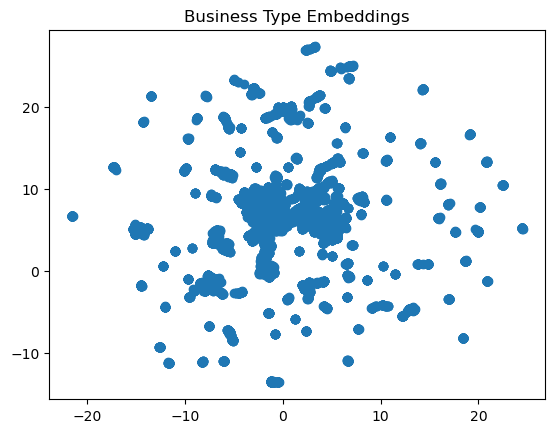

In [6]:
umap_vis = umap.UMAP(n_components=2, metric='cosine').fit_transform(encodings)


plt.scatter(umap_vis.T[0],umap_vis.T[1])

plt.title('Business Type Embeddings')
plt.show()

2
3
4
5
6
7
8
9
10
11
12
13
14


<Axes: title={'center': 'Silhouette Score vs Number of Clusters'}, xlabel='Number of Clusters', ylabel='Silhouette Score'>

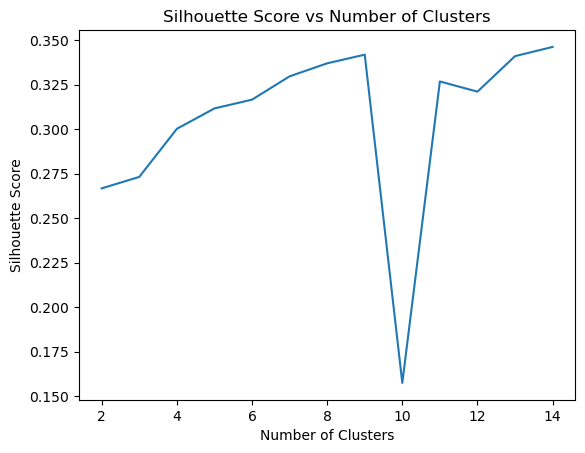

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


scores = pd.Series(name='score')

for i in range(2,15):
    print(i)
    kmeans = KMeans(n_clusters=i)
    _cluster_labels = kmeans.fit_predict(encodings)
    scores[i] = silhouette_score(encodings, _cluster_labels,metric='cosine')

scores.plot.line(
    xlabel='Number of Clusters',
    ylabel='Silhouette Score',
    title='Silhouette Score vs Number of Clusters'
)

In [8]:
umapd = umap.UMAP(n_components=8, metric='cosine').fit_transform(encodings)
cluster_labels = hdbscan.HDBSCAN(min_cluster_size=30,metric='euclidean').fit_predict(umapd)


In [9]:
silhouette_score(encodings, cluster_labels,metric='cosine')

-0.053717195987701416

In [10]:
data2 = data

data2['cluster'] = cluster_labels

data2.sort_values(by='cluster').where(lambda x: x['cluster'] !=-1).dropna()


,DBA,Business type,Bus address,Start date,Close date,License description,Rate type (STD),type,long,lat,closure_time,censor,zone,parcel,sq(ft),is_downtown_association,zone_type,is_home_occ,ft to downtown,cluster
177,730 Boysen LLC,Rental- Residential,730 BOYSEN AVE,1982-07-01,2016-06-28,Residential Rental Property,Residential Rental,Rental,-120.672333,35.296654,15954.0,1.0,R-4,052-331-019,17670.043231,False,Residential,False,5727.332819,0.0
11922,S C M S,Rental- Residential,214 VIA SAN BLAS,2010-10-06,2018-02-28,Residential Rental Property,Residential Rental,Rental,-120.667383,35.256573,5630.0,1.0,R-2,053-184-001,135865.558929,False,Residential,False,7079.402302,0.0
11751,Ron Shapiro,Rental- Residential,1185 E FOOTHILL BLVD APT 36,2011-04-28,2015-07-14,Residential Rental Property,Residential Rental,Rental,-120.664289,35.294765,5426.0,1.0,R-4,052-184-037,49528.171552,False,Residential,False,4069.578545,0.0
11582,Robert & Paula Coomer,Rental- Residential,74 CONTENTA CT,2011-03-22,2015-01-31,Residential Rental Property,Residential Rental,Rental,-120.679725,35.241622,5463.0,1.0,R-1,053-263-072,4022.462373,False,Residential,False,13150.848240,0.0
11451,Richard Brooks,Rental- Residential,108 LOS CERROS DR,2010-10-27,2017-06-30,Residential Rental Property,Residential Rental,Rental,-120.686202,35.294152,5609.0,1.0,R-1,052-312-032,7763.360684,False,Residential,False,7734.077930,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3397,"Cuesta Geotechnical, Inc.",Home Occupation,623 GROVE ST,1987-04-07,2023-04-17,Consulting Geologist,Professional Service,Service,-120.656263,35.290384,14213.0,1.0,R-1,001-056-050,12607.190900,False,Residential,True,2736.034190,127.0
11967,Sabrina Elizabeth,Home Occupation,3591 SACRAMENTO DR UNIT 10,2010-07-14,2011-12-16,Provides Organizational Expertise To Clients,General Service,Service,-120.642082,35.255206,5714.0,1.0,C,053-234-003,76045.203660,False,Commercial,True,10024.543733,127.0
2589,Central Coast Technology Specialists Group,Home Occupation,1022 LEFF ST STE A,2011-03-08,2011-06-30,Technology Consulting,General Service,Service,-120.656331,35.276761,5477.0,1.0,R-3,003-553-015,2328.536773,False,Residential,True,1221.936329,127.0
6,1 Dream Education,Home Occupation,357 SAGE ST,2015-05-05,2022-05-31,Education Consulting,Professional Service,Service,-120.662625,35.255449,3958.0,1.0,R-1,053-432-027,5401.547021,False,Residential,True,7553.345910,127.0


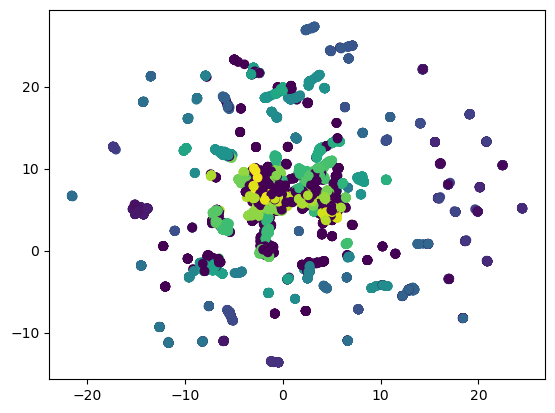

In [11]:
plt.scatter(umap_vis.T[0],umap_vis.T[1],c=cluster_labels)

In [134]:
import sksurv.nonparametric as np

data['Business type']

0                    Apparel/Accessories
1                 Misc Business Services
2                    Rental- Residential
3                             Restaurant
4                           Beauty Salon
                      ...               
15327                    Home Occupation
15328    Auto Mechanic/Detailer/Services
15329                             Retail
15330            Wholesale, Distributors
15331                Rental- Residential
Name: Business type, Length: 15162, dtype: object

In [127]:
np.kaplan_meier_estimator()

<function sksurv.nonparametric.kaplan_meier_estimator(event, time_exit, time_enter=None, time_min=None, reverse=False, conf_level=0.95, conf_type=None)>